In [1]:
#####################################

from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

FS_IN = 2560e6
DECIMATION = 256
FS_OUT = FS_IN / DECIMATION       # 10 MSPS



FRAME_SAMPLES = 256               # output samples
INPUT_SAMPLES = FRAME_SAMPLES * DECIMATION



# ============================================================
# Configure clocks and load overlay
# ============================================================


ol = Overlay("top_design.bit")

dma = ol.axi_dma_0

In [2]:
AMPLITUDE = 1 * 32767

In [3]:
rx_buffer = allocate(
    shape=(FRAME_SAMPLES,),
    dtype=np.uint32
)

In [4]:
dma.recvchannel.transfer(rx_buffer)
dma.recvchannel.wait()

Maximum complex magnitude: 30815.49
Maximum I magnitude: 29396
Maximum Q magnitude: 28627
Peak frequency: -1.015625 MHz
Peak level:     -1.82 dBFS
Input samples  : 65536
Output samples : 256
Input Fs       : 2560.0 MSPS
Output Fs      : 10.0 MSPS


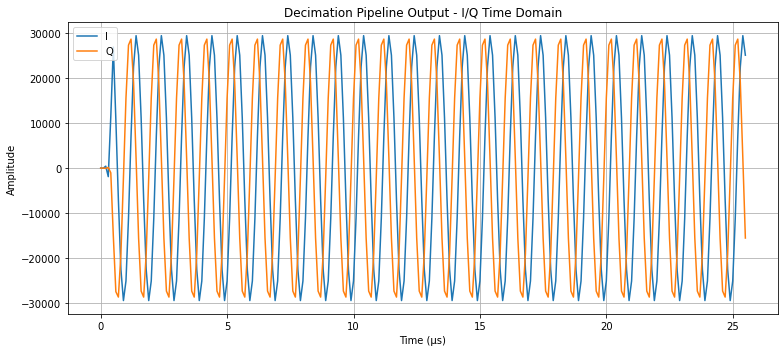

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


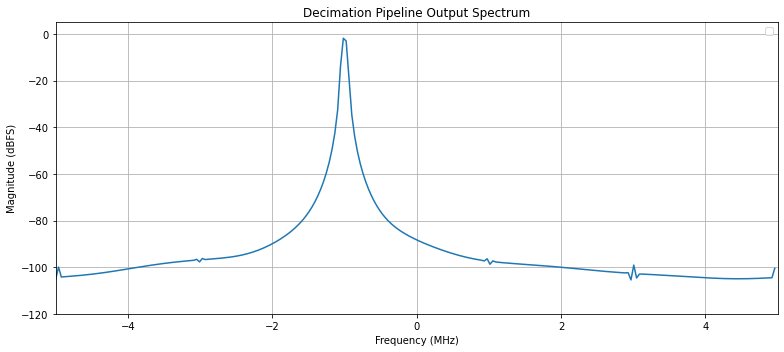

In [5]:
# Copy out of physically contiguous buffer

# ============================================================
# Unpack DMA data into complex I/Q
#
# Packed 32-bit word:
#
# [31:16] = Q signed int16
# [15:0]  = I signed int16
#
# x[n] = I[n] + jQ[n]
# ============================================================

packed = np.asarray(rx_buffer, dtype=np.uint32)

# Extract lower and upper 16-bit samples
i_u16 = ( packed        & 0xFFFF).astype(np.uint16)
q_u16 = ((packed >> 16) & 0xFFFF).astype(np.uint16)

# Reinterpret as signed int16
I = i_u16.view(np.int16)
Q = q_u16.view(np.int16)

# Construct complex IQ signal
x = I.astype(np.float64) + 1j * Q.astype(np.float64)


# ============================================================
# Remove FIR/startup transient
# ============================================================

transient = 0

I = I[transient:]
Q = Q[transient:]
x = x[transient:]

N = len(x)


# ============================================================
# Time-domain axis
# ============================================================

t_out = np.arange(N) / FS_OUT


# ============================================================
# FFT of complex IQ output
# ============================================================

window = np.hanning(N)

# IMPORTANT:
# Do not cast x to float64 here.
# x must remain complex so both I and Q are included.
Y = np.fft.fftshift(
    np.fft.fft(
        x * window
    )
)

# Correct for Hann-window coherent gain
Y = Y / np.sum(window)

# Frequency axis
f = np.fft.fftshift(
    np.fft.fftfreq(
        N,
        d=1.0 / FS_OUT
    )
)


# ============================================================
# Time-domain magnitude
# ============================================================

complex_mag = np.abs(x)

mag_max = np.max(complex_mag)

print(f"Maximum complex magnitude: {mag_max:.2f}")

print(f"Maximum I magnitude: {np.max(np.abs(I.astype(np.int32)))}")
print(f"Maximum Q magnitude: {np.max(np.abs(Q.astype(np.int32)))}")


# ============================================================
# FFT magnitude in dBFS
#
# For complex IQ:
#
#     x[n] = A * exp(j*2*pi*f*n/Fs)
#
# gives an FFT peak of approximately A after coherent-gain
# correction.
#
# Therefore 32768 corresponds to 0 dBFS.
# ============================================================

mag_dbfs = 20.0 * np.log10(
    np.maximum(
        np.abs(Y) / 32768.0,
        1e-12
    )
)


# ============================================================
# Find spectral peak
# ============================================================

peak_idx = np.argmax(mag_dbfs)

peak_freq  = f[peak_idx]
peak_level = mag_dbfs[peak_idx]

print(f"Peak frequency: {peak_freq / 1e6:.6f} MHz")
print(f"Peak level:     {peak_level:.2f} dBFS")


print(f"Input samples  : {INPUT_SAMPLES}")
print(f"Output samples : {FRAME_SAMPLES}")
print(f"Input Fs       : {FS_IN/1e6:.1f} MSPS")
print(f"Output Fs      : {FS_OUT/1e6:.1f} MSPS")


# ============================================================
# Time-domain plot - I and Q
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    t_out * 1e6,
    I,
    label="I"
)

plt.plot(
    t_out * 1e6,
    Q,
    label="Q"
)

plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.title("Decimation Pipeline Output - I/Q Time Domain")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# Frequency-domain plot
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    f / 1e6,
    mag_dbfs
)


plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dBFS)")
plt.title("Decimation Pipeline Output Spectrum")

plt.xlim(
    -FS_OUT / 2e6,
    FS_OUT / 2e6
)

plt.ylim(-120, 5)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Free buffers
# ============================================================

rx_buffer.freebuffer()